## ***Install and Import Libraries***

In [ ]:
pip install -q scipy==1.13.1 yfinance pandas-ta transformers torch xgboost lightgbm prophet statsmodels mlflow dagshub boto3 evidently nltk python-dotenv tabulate plotly

In [2]:
import os
import json
import pickle
import warnings
import joblib
import logging
import time
from datetime import datetime, timedelta
from statistics import mean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import tensorflow as tf
import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import yfinance as yf
import pandas_ta as ta
import requests
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import mlflow
import mlflow.sklearn
import mlflow.tensorflow
import boto3
import psycopg2
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, accuracy_score, f1_score, classification_report
from kaggle_secrets import UserSecretsClient

2026-03-14 06:28:25.609182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773469705.631420   43005 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773469705.638045   43005 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773469705.656369   43005 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773469705.656390   43005 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773469705.656392   43005 computation_placer.cc:177] computation placer alr

## ***Config***

In [3]:
nltk.download("vader_lexicon", quiet=True)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: True


In [4]:
secrets = UserSecretsClient()
DAGSHUB_USERNAME = secrets.get_secret("DAGSHUB_USERNAME")
DAGSHUB_TOKEN = secrets.get_secret("DAGSHUB_TOKEN")
DATABASE_URL = secrets.get_secret("DATABASE_URL")
R2_ENDPOINT_URL = secrets.get_secret("R2_ENDPOINT_URL")
R2_ACCESS_KEY_ID = secrets.get_secret("R2_ACCESS_KEY_ID")
R2_SECRET_ACCESS_KEY = secrets.get_secret("R2_SECRET_ACCESS_KEY")
MLFLOW_EXPERIMENT_NAME = "marketpulse"
MLFLOW_TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/marketpulse.mlflow"
R2_BUCKET_NAME = "marketpulse-artifacts"

In [5]:
TICKERS = ["^NDX", "SPY", "AAPL", "MSFT", "GOOGL", "NVDA", "TSLA", "META", "JPM", "AMZN"]

TICKER_QUERY_MAP = {
    "^NDX":  "Nasdaq 100 index technology stocks",
    "SPY":   "S&P 500 stock market economy",
    "AAPL":  "Apple Inc earnings revenue iPhone",
    "MSFT":  "Microsoft earnings cloud Azure",
    "GOOGL": "Google Alphabet earnings search advertising",
    "NVDA":  "Nvidia GPU AI chips semiconductors",
    "TSLA":  "Tesla electric vehicles Elon Musk",
    "META":  "Meta Facebook Instagram advertising",
    "JPM":   "JPMorgan Chase bank earnings interest rates",
    "AMZN":  "Amazon AWS cloud ecommerce earnings"
}

# Keyword lists used to filter yfinance news by relevance
TICKER_KEYWORDS = {
    "^NDX":  ["nasdaq", "ndx", "tech", "index"],
    "SPY":   ["s&p", "spy", "market", "economy", "stocks"],
    "AAPL":  ["apple", "iphone", "aapl", "tim cook"],
    "MSFT":  ["microsoft", "msft", "azure", "windows", "copilot"],
    "GOOGL": ["google", "alphabet", "googl", "search", "youtube"],
    "NVDA":  ["nvidia", "nvda", "gpu", "cuda", "jensen"],
    "TSLA":  ["tesla", "tsla", "elon", "electric vehicle", "ev"],
    "META":  ["meta", "facebook", "instagram", "zuckerberg", "whatsapp"],
    "JPM":   ["jpmorgan", "jpm", "chase", "dimon", "bank"],
    "AMZN":  ["amazon", "amzn", "aws", "bezos", "prime"]
}

In [6]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2026-02-28"
SEQUENCE_LEN = 10
TRAIN_SPLIT = 0.85
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.02
RANDOM_STATE = 42
FINBERT_MODEL = "ProsusAI/finbert"
NEWS_PER_DAY = 5

In [7]:
RSI_PERIOD = 14
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9
BB_PERIOD = 20
EMA_PERIODS = [9, 21, 50]

In [8]:
OUTPUT_DIR = "/kaggle/working/marketpulse"
MODELS_DIR = f"{OUTPUT_DIR}/models"
PLOTS_DIR  = f"{OUTPUT_DIR}/plots"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Tickers: {TICKERS}")
print(f"Training period: {TRAIN_START} to {TRAIN_END}")

Tickers: ['^NDX', 'SPY', 'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'TSLA', 'META', 'JPM', 'AMZN']
Training period: 2020-01-01 to 2026-02-28


## ***MLFlow Setup***

In [9]:
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"]  = DAGSHUB_TOKEN

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("marketpulse")

print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")

MLflow tracking URI: https://dagshub.com/Manjot7/marketpulse.mlflow


## ***Price Data Fetcher***

In [10]:
def fetch_historical(ticker, start=TRAIN_START, end=TRAIN_END):
    """
    Download OHLCV history for a single ticker from Yahoo Finance.
    Returns a cleaned DataFrame with Date as a string column.
    """
    raw = yf.download(ticker, start=start, end=end, progress=False)

    if raw.empty:
        logger.warning(f"No data for {ticker}")
        return pd.DataFrame()

    raw = raw.reset_index()
    raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
    raw["Ticker"] = ticker
    raw["Date"]   = pd.to_datetime(raw["Date"]).dt.date.astype(str)
    raw = raw[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]].dropna()

    logger.info(f"{ticker}: {len(raw)} trading days fetched")
    time.sleep(0.3)
    return raw

In [11]:
def fetch_all_tickers():
    frames = [fetch_historical(t) for t in TICKERS]
    frames = [f for f in frames if not f.empty]
    combined = pd.concat(frames, ignore_index=True)
    logger.info(f"Total price rows: {len(combined)}")
    return combined

In [12]:
print("Fetching price data for all tickers...")
price_df = fetch_all_tickers()
print(f"Price data shape: {price_df.shape}")
price_df.head()

Fetching price data for all tickers...


2026-03-14 06:28:45,785 INFO ^NDX: 1547 trading days fetched
2026-03-14 06:28:46,256 INFO SPY: 1547 trading days fetched
2026-03-14 06:28:46,717 INFO AAPL: 1547 trading days fetched
2026-03-14 06:28:47,153 INFO MSFT: 1547 trading days fetched
2026-03-14 06:28:47,586 INFO GOOGL: 1547 trading days fetched
2026-03-14 06:28:48,030 INFO NVDA: 1547 trading days fetched
2026-03-14 06:28:48,437 INFO TSLA: 1547 trading days fetched
2026-03-14 06:28:48,863 INFO META: 1547 trading days fetched
2026-03-14 06:28:49,328 INFO JPM: 1547 trading days fetched
2026-03-14 06:28:49,743 INFO AMZN: 1547 trading days fetched
2026-03-14 06:28:50,046 INFO Total price rows: 15470


Price data shape: (15470, 7)


,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,^NDX,8802.219727,8873.629883,8786.900391,8872.219727,2862700000
1,2020-01-03,^NDX,8755.169922,8843.650391,8755.169922,8793.900391,2586520000
2,2020-01-06,^NDX,8713.889648,8849.980469,8713.889648,8848.519531,2810450000
3,2020-01-07,^NDX,8857.139648,8872.469727,8821.679688,8846.450195,2381740000
4,2020-01-08,^NDX,8845.450195,8953.549805,8834.940430,8912.370117,2472620000


## ***Technical Indicators***

In [13]:
def compute_indicators(df):
    """
    Compute RSI, MACD, Bollinger Bands, EMA, OBV, ATR and momentum features.
    Drops NaN rows from lookback periods.
    """
    df     = df.copy().sort_values("Date").reset_index(drop=True)
    close  = df["Close"]
    high   = df["High"]
    low    = df["Low"]
    volume = df["Volume"]

    df["rsi"] = ta.rsi(close, length=RSI_PERIOD)

    macd = ta.macd(close, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL)
    if macd is not None:
        df["macd"]        = macd[f"MACD_{MACD_FAST}_{MACD_SLOW}_{MACD_SIGNAL}"]
        df["macd_signal"] = macd[f"MACDs_{MACD_FAST}_{MACD_SLOW}_{MACD_SIGNAL}"]
        df["macd_hist"]   = macd[f"MACDh_{MACD_FAST}_{MACD_SLOW}_{MACD_SIGNAL}"]

    bb = ta.bbands(close, length=BB_PERIOD)
    if bb is not None:
        bb_cols = bb.columns.tolist()
        upper_col = [c for c in bb_cols if c.startswith("BBU")][0]
        mid_col   = [c for c in bb_cols if c.startswith("BBM")][0]
        lower_col = [c for c in bb_cols if c.startswith("BBL")][0]
        df["bb_upper"] = bb[upper_col]
        df["bb_mid"]   = bb[mid_col]
        df["bb_lower"] = bb[lower_col]

    df["bb_width"] = df["bb_upper"] - df["bb_lower"]

    for period in EMA_PERIODS:
        df[f"ema_{period}"] = ta.ema(close, length=period)

    df["obv"] = ta.obv(close, volume)
    df["atr"] = ta.atr(high, low, close, length=14)

    df["price_change_1d"]  = close.pct_change(1)
    df["price_change_5d"]  = close.pct_change(5)
    df["price_change_10d"] = close.pct_change(10)
    df["volatility_10d"]   = close.pct_change().rolling(10).std()
    df["volatility_20d"]   = close.pct_change().rolling(20).std()
    df["volume_ma_10"]     = volume.rolling(10).mean()
    df["volume_ratio"]     = volume / df["volume_ma_10"]

    # Direction label for classification: 1 if tomorrow's price is higher
    df["direction"] = (close.shift(-1) > close).astype(int)

    df = df.dropna()
    return df

In [14]:
def compute_all_tickers(combined_df):
    frames = []
    for ticker in combined_df["Ticker"].unique():
        ticker_df = combined_df[combined_df["Ticker"] == ticker].copy()
        ticker_df = compute_indicators(ticker_df)
        frames.append(ticker_df)
        logger.info(f"{ticker}: {len(ticker_df)} rows after indicators")
    return pd.concat(frames, ignore_index=True)

In [15]:
print("Computing technical indicators...")
indicators_df = compute_all_tickers(price_df)
print(f"Indicators shape: {indicators_df.shape}")
print(f"Columns: {list(indicators_df.columns)}")

Computing technical indicators...


2026-03-14 06:28:50,721 INFO ^NDX: 1498 rows after indicators
2026-03-14 06:28:50,742 INFO SPY: 1498 rows after indicators
2026-03-14 06:28:50,762 INFO AAPL: 1498 rows after indicators
2026-03-14 06:28:50,783 INFO MSFT: 1498 rows after indicators
2026-03-14 06:28:50,802 INFO GOOGL: 1498 rows after indicators
2026-03-14 06:28:50,822 INFO NVDA: 1498 rows after indicators
2026-03-14 06:28:50,842 INFO TSLA: 1498 rows after indicators
2026-03-14 06:28:50,861 INFO META: 1498 rows after indicators
2026-03-14 06:28:50,881 INFO JPM: 1498 rows after indicators
2026-03-14 06:28:50,902 INFO AMZN: 1498 rows after indicators


Indicators shape: (14980, 28)
Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_mid', 'bb_lower', 'bb_width', 'ema_9', 'ema_21', 'ema_50', 'obv', 'atr', 'price_change_1d', 'price_change_5d', 'price_change_10d', 'volatility_10d', 'volatility_20d', 'volume_ma_10', 'volume_ratio', 'direction']


## ***News Headlines Fetcher***

In [16]:
def fetch_headlines(ticker, date_str=None):
    try:
        news = yf.Ticker(ticker).news
        headlines = [
            item.get("content", {}).get("title", "")
            for item in news
            if item.get("content", {}).get("title", "")
        ]
        logger.debug(f"{ticker}: {len(headlines)} headlines fetched")
        return headlines

    except Exception as e:
        logger.warning(f"yfinance news fetch failed for {ticker}: {e}")
        return []

## ***FinBERT Sentiment Scorer***

In [17]:
print("Loading FinBERT model...")
_finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
_finbert_model     = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
_finbert_pipeline  = pipeline(
    "sentiment-analysis",
    model=_finbert_model,
    tokenizer=_finbert_tokenizer,
    truncation=True,
    max_length=512
)
print("FinBERT loaded successfully")

2026-03-14 06:28:51,086 INFO HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-14 06:28:51,096 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"


Loading FinBERT model...


2026-03-14 06:28:51,173 INFO HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-14 06:28:51,184 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-14 06:28:51,264 INFO HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-14 06:28:51,345 INFO HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-03-14 06:28:51,441 INFO HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-14 06:28:51,442 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster d

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

2026-03-14 06:28:52,220 INFO HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors.index.json "HTTP/1.1 404 Not Found"
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-14 06:28:52,418 INFO HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


FinBERT loaded successfully


In [18]:
def finbert_score(headline):
    """
    Score a single headline with FinBERT.
    Returns float in [-1, 1].
    """
    if not headline or not headline.strip():
        return 0.0
    try:
        result = _finbert_pipeline(headline[:512])[0]
        label  = result["label"].lower()
        score  = result["score"]
        if label == "positive":
            return round(score, 6)
        elif label == "negative":
            return round(-score, 6)
        return 0.0
    except Exception:
        return 0.0

In [19]:
def vader_score(headline):
    """
    Score a single headline with VADER.
    Returns float in [-1, 1].
    """
    if not headline or not headline.strip():
        return 0.0
    try:
        analyzer = SentimentIntensityAnalyzer()
        scores   = analyzer.polarity_scores(headline)
        pos, neg, neu = scores["pos"], scores["neg"], scores["neu"]
        dominant = max(pos, neg, neu)
        if dominant == pos:
            return round(pos, 6)
        elif dominant == neg:
            return round(-neg, 6)
        return 0.0
    except Exception:
        return 0.0

In [20]:
def score_headlines(headlines):
    """
    Score a list of headlines. Returns (mean_finbert, mean_vader).
    """
    if not headlines:
        return 0.0, 0.0
    fb = [finbert_score(h) for h in headlines]
    vd = [vader_score(h) for h in headlines]
    return round(mean(fb), 6), round(mean(vd), 6)

## ***Fetch Sentiment for All Tickers***

In [21]:
print("Fetching headlines via yfinance and scoring sentiment...")

sentiment_records = []

for ticker in TICKERS:
    print(f"  {ticker}: fetching headlines...", end=" ", flush=True)

    try:
        headlines = fetch_headlines(ticker)
        print(f"{len(headlines)} found")
    except Exception as e:
        print(f"FAILED ({e}), using empty headlines")
        headlines = []

    fb_score, vd_score = score_headlines(headlines)
    print(f"    finbert={fb_score:.4f}  vader={vd_score:.4f}")

    ticker_dates = indicators_df[indicators_df["Ticker"] == ticker]["Date"].tolist()
    for date_str in ticker_dates:
        sentiment_records.append({
            "Date":          date_str,
            "Ticker":        ticker,
            "headlines":     headlines,
            "finbert_score": fb_score,
            "vader_score":   vd_score
        })

    time.sleep(0.1)

Fetching headlines via yfinance and scoring sentiment...
  ^NDX: fetching headlines... 10 found
    finbert=-0.2262  vader=-0.1699
  SPY: fetching headlines... 

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


10 found
    finbert=-0.0081  vader=-0.0516
  AAPL: fetching headlines... 10 found
    finbert=-0.0008  vader=0.0000
  MSFT: fetching headlines... 10 found
    finbert=0.0384  vader=0.0000
  GOOGL: fetching headlines... 10 found
    finbert=0.1516  vader=0.0000
  NVDA: fetching headlines... 10 found
    finbert=-0.0581  vader=0.0000
  TSLA: fetching headlines... 10 found
    finbert=-0.1729  vader=0.0000
  META: fetching headlines... 10 found
    finbert=-0.4323  vader=0.0000
  JPM: fetching headlines... 10 found
    finbert=-0.1787  vader=-0.0521
  AMZN: fetching headlines... 10 found
    finbert=0.0765  vader=0.0000


In [22]:
sentiment_df = pd.DataFrame(sentiment_records)
print(f"Sentiment DataFrame shape: {sentiment_df.shape}")

Sentiment DataFrame shape: (14980, 5)


## ***Merge Features***

In [23]:
def merge_features(indicators_df, sentiment_df):
    df = indicators_df.copy()
    if not sentiment_df.empty:
        sent_cols = sentiment_df[["Date", "Ticker", "finbert_score", "vader_score"]]
        df = df.merge(sent_cols, on=["Date", "Ticker"], how="left")
        df["finbert_score"] = df.groupby("Ticker")["finbert_score"].ffill().bfill().fillna(0.0)
        df["vader_score"]   = df.groupby("Ticker")["vader_score"].ffill().bfill().fillna(0.0)
    else:
        df["finbert_score"] = 0.0
        df["vader_score"]   = 0.0
    return df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

In [24]:
print("Merging features...")
features_df = merge_features(indicators_df, sentiment_df)
print(f"Features shape: {features_df.shape}")

Merging features...
Features shape: (14980, 30)


In [25]:
SEQUENCE_FEATURES = [
    "Open", "High", "Low", "Volume",
    "finbert_score", "vader_score",
    "rsi", "macd", "bb_width",
    "price_change_1d", "volatility_10d"
]

In [26]:
TABULAR_FEATURES = [
    "Open", "High", "Low", "Close", "Volume",
    "rsi", "macd", "macd_signal", "macd_hist",
    "bb_upper", "bb_lower", "bb_width",
    "ema_9", "ema_21", "ema_50",
    "obv", "atr",
    "price_change_1d", "price_change_5d", "price_change_10d",
    "volatility_10d", "volatility_20d", "volume_ratio",
    "finbert_score", "vader_score"
]

## ***Sequence Builder***

In [27]:
def build_sequences(ticker_df, feature_cols, target_col="Close", seq_len=SEQUENCE_LEN):
    data   = ticker_df[feature_cols + [target_col]].values.astype(float)
    scaler = MinMaxScaler()
    data   = scaler.fit_transform(data)
    X, y   = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len, :-1])
        y.append(data[i + seq_len, -1])
    return np.array(X), np.array(y), scaler

In [28]:
def split_sequences(X, y, split=TRAIN_SPLIT):
    idx = int(len(X) * split)
    return X[:idx], X[idx:], y[:idx], y[idx:]

In [29]:
def inverse_transform_predictions(y_pred_scaled, y_true_scaled, scaler, n_features):
    """
    Inverse transform scaled predictions back to original price scale.
    """
    def _inverse(arr):
        dummy = np.zeros((len(arr), n_features))
        dummy[:, -1] = arr
        return scaler.inverse_transform(dummy)[:, -1]
    return _inverse(y_pred_scaled), _inverse(y_true_scaled)

## ***Evaluation Functions***

In [30]:
def regression_metrics(y_true, y_pred, model_name, ticker):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    actual_dir    = np.sign(np.diff(y_true))
    predicted_dir = np.sign(np.diff(y_pred))
    dir_acc       = np.mean(actual_dir == predicted_dir)

    print(f"  {model_name} ({ticker}): MAE={mae:.2f} | MAPE={mape*100:.3f}% | RMSE={rmse:.2f} | DirAcc={dir_acc:.3f}")

    return {
        "model":        model_name,
        "ticker":       ticker,
        "mae":          round(mae, 4),
        "mape_pct":     round(mape * 100, 4),
        "rmse":         round(rmse, 4),
        "accuracy_pct": round((1 - mape) * 100, 4),
        "dir_accuracy": round(dir_acc, 4),
        "type":         "regression"
    }

In [31]:
def classification_metrics_fn(y_true, y_pred, model_name, ticker):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"  {model_name} ({ticker}): Accuracy={acc:.4f} | F1={f1:.4f}")
    return {
        "model":    model_name,
        "ticker":   ticker,
        "accuracy": round(acc, 4),
        "f1_score": round(f1, 4),
        "type":     "classification"
    }

## ***Model Definitions***

In [32]:
def build_lstm_baseline(input_shape):
    tf.random.set_seed(RANDOM_STATE)
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.LSTM(50, activation="tanh", return_sequences=True),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.LSTM(30, activation="tanh", return_sequences=True),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.LSTM(20, activation="tanh", return_sequences=False),
        tf.keras.layers.Dropout(0.01),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

In [33]:
def build_finbert_lstm(input_shape):
    tf.random.set_seed(RANDOM_STATE)
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.LSTM(70, activation="tanh", return_sequences=True),
        tf.keras.layers.LSTM(30, activation="tanh", return_sequences=True),
        tf.keras.layers.LSTM(10, activation="tanh", return_sequences=False),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

In [34]:
def build_gru(input_shape):
    tf.random.set_seed(RANDOM_STATE)
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.GRU(50, activation="tanh", return_sequences=True),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.GRU(30, activation="tanh", return_sequences=True),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.GRU(20, activation="tanh", return_sequences=False),
        tf.keras.layers.Dropout(0.01),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

In [35]:
def build_bilstm(input_shape):
    tf.random.set_seed(RANDOM_STATE)
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(50, activation="tanh", return_sequences=True)),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(30, activation="tanh", return_sequences=False)),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

In [36]:
def build_cnn_lstm(input_shape):
    tf.random.set_seed(RANDOM_STATE)
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        tf.keras.layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.LSTM(50, activation="tanh", return_sequences=True),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.LSTM(30, activation="tanh", return_sequences=False),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

In [37]:
def train_keras_model(model, X_train, y_train, X_val, y_val, model_name):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    print(f"  {model_name}: trained {len(history.history['loss'])} epochs | final val_loss={history.history['val_loss'][-1]:.6f}")
    return model, history

## ***MLFlow Logging Helper***

In [38]:
def log_to_mlflow(model_name, ticker, params, metrics, model_obj=None):
    run_name = f"{model_name}_{ticker}"
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model", model_name)
        mlflow.set_tag("ticker", ticker)
        mlflow.log_params(params)
        mlflow.log_metrics({k: v for k, v in metrics.items()
                            if isinstance(v, (int, float)) and k not in ("model", "ticker", "type")})
        run_id = mlflow.active_run().info.run_id
    return run_id

## ***Cloudflare R2 Upload Helper***

In [39]:
def upload_to_r2(local_path, r2_key):
    if not all([R2_ENDPOINT_URL, R2_ACCESS_KEY_ID, R2_SECRET_ACCESS_KEY]):
        logger.warning("R2 credentials not set. Skipping upload.")
        return
    try:
        client = boto3.client(
            "s3",
            endpoint_url=R2_ENDPOINT_URL,
            aws_access_key_id=R2_ACCESS_KEY_ID,
            aws_secret_access_key=R2_SECRET_ACCESS_KEY
        )
        client.upload_file(local_path, R2_BUCKET_NAME, r2_key)
        print(f"  Uploaded to R2: {r2_key}")
    except Exception as e:
        logger.warning(f"R2 upload failed: {e}")

In [40]:
def save_and_upload_model(model, model_name, ticker, scaler=None):
    if hasattr(model, 'save'):
        path = f"{MODELS_DIR}/{model_name}_{ticker}.keras"
    else:
        path = f"{MODELS_DIR}/{model_name}_{ticker}.pkl"
    
    try:
        if hasattr(model, 'save'):
            model.save(path)
        else:
            joblib.dump(model, path)
        upload_to_r2(path, f"models/{ticker}/{model_name}/{model_name}_{ticker}")

        # Save scaler alongside model so processor can inverse-transform predictions
        if scaler is not None:
            scaler_path = f"{MODELS_DIR}/{model_name}_{ticker}_scaler.pkl"
            joblib.dump(scaler, scaler_path)
            upload_to_r2(scaler_path, f"models/{ticker}/{model_name}/{model_name}_{ticker}_scaler")
            print(f"  Scaler uploaded to R2 for {model_name}/{ticker}")
    except Exception as e:
        logger.warning(f"Model save failed: {e}")

## ***DB Helper***

In [41]:
def write_metrics_to_db(metrics):
    if not DATABASE_URL:
        return
    try:
        conn   = psycopg2.connect(DATABASE_URL)
        cursor = conn.cursor()
        cursor.execute(
            """
            INSERT INTO model_metrics
                (model_name, ticker, mae, mape, rmse, dir_accuracy, trained_at)
            VALUES (%s, %s, %s, %s, %s, %s, NOW())
            ON CONFLICT (model_name, ticker) DO UPDATE
                SET mae=EXCLUDED.mae, mape=EXCLUDED.mape,
                    rmse=EXCLUDED.rmse, dir_accuracy=EXCLUDED.dir_accuracy,
                    trained_at=NOW()
            """,
            (
                metrics["model"], metrics["ticker"],
                float(metrics.get("mae", 0) or 0),
                float(metrics.get("mape_pct", 0) or 0),
                float(metrics.get("rmse", 0) or 0),
                float(metrics.get("dir_accuracy", 0) or 0)
            )
        )
        conn.commit()
        conn.close()
    except Exception as e:
        logger.warning(f"DB write failed: {e}")

## ***Train Models for One Ticker***

In [42]:
def train_dl_models(ticker_df, ticker):
    """
    Train all 5 deep learning models for a single ticker.
    Returns list of metrics dicts.
    """
    print(f"\n  Training deep learning models for {ticker}...")

    X, y, scaler = build_sequences(ticker_df, SEQUENCE_FEATURES)
    X_tr, X_te, y_tr, y_te = split_sequences(X, y)

    val_idx  = int(len(X_tr) * 0.9)
    X_val    = X_tr[val_idx:]
    y_val    = y_tr[val_idx:]
    X_train  = X_tr[:val_idx]
    y_train  = y_tr[:val_idx]

    input_shape = (X_train.shape[1], X_train.shape[2])
    n_features  = len(SEQUENCE_FEATURES) + 1

    dl_specs = [
        ("LSTM-Baseline",  build_lstm_baseline),
        ("FinBERT-LSTM",   build_finbert_lstm),
        ("GRU",            build_gru),
        ("BiLSTM",         build_bilstm),
        ("CNN-LSTM",       build_cnn_lstm)
    ]

    results   = []
    all_preds = {}

    for model_name, builder in dl_specs:
        try:
            model, history = train_keras_model(
                builder(input_shape), X_train, y_train, X_val, y_val, model_name
            )

            y_pred_s = model.predict(X_te, verbose=0).flatten()
            y_pred, y_true = inverse_transform_predictions(y_pred_s, y_te, scaler, n_features)

            all_preds[model_name] = y_pred

            metrics = regression_metrics(y_true, y_pred, model_name, ticker)
            params  = {"sequence_length": SEQUENCE_LEN, "train_split": TRAIN_SPLIT, "ticker": ticker}

            log_to_mlflow(model_name, ticker, params, metrics)
            write_metrics_to_db(metrics)
            save_and_upload_model(model, model_name, ticker, scaler=scaler)

            results.append({**metrics, "y_true": y_true, "y_pred": y_pred})

        except Exception as e:
            print(f"  ERROR: {model_name} failed for {ticker}: {e}")

    return results, all_preds

In [43]:
def train_tabular_models(ticker_df, ticker):
    """
    Train XGBoost, LightGBM (regression + classification) and Random Forest (classification).
    """
    print(f"\n  Training tabular models for {ticker}...")

    df_clean = ticker_df.dropna(subset=TABULAR_FEATURES + ["Close", "direction"])

    X   = df_clean[TABULAR_FEATURES].values
    y_r = df_clean["Close"].values
    y_c = df_clean["direction"].values

    split_reg = int(len(X) * TRAIN_SPLIT)
    split_val = int(split_reg * 0.9)

    X_train_r = X[:split_val]
    X_val_r   = X[split_val:split_reg]
    X_test_r  = X[split_reg:]
    y_train_r = y_r[:split_val]
    y_val_r   = y_r[split_val:split_reg]
    y_test_r  = y_r[split_reg:]

    X_train_c = X[:split_val]
    X_val_c   = X[split_val:split_reg]
    X_test_c  = X[split_reg:]
    y_train_c = y_c[:split_val]
    y_val_c   = y_c[split_val:split_reg]
    y_test_c  = y_c[split_reg:]

    results = []

    xgb_reg = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, early_stopping_rounds=20, eval_metric="mae"
    )
    xgb_reg.fit(X_train_r, y_train_r, eval_set=[(X_val_r, y_val_r)], verbose=False)
    y_pred = xgb_reg.predict(X_test_r)
    metrics = regression_metrics(y_test_r, y_pred, "XGBoost-Regression", ticker)
    log_to_mlflow("XGBoost-Regression", ticker, {"ticker": ticker}, metrics)
    write_metrics_to_db(metrics)
    save_and_upload_model(xgb_reg, "XGBoost-Regression", ticker)
    results.append({**metrics, "y_true": y_test_r, "y_pred": y_pred})

    lgb_reg = lgb.LGBMRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    lgb_reg.fit(
        X_train_r, y_train_r,
        eval_set=[(X_val_r, y_val_r)],
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(-1)]
    )
    y_pred = lgb_reg.predict(X_test_r)
    metrics = regression_metrics(y_test_r, y_pred, "LightGBM-Regression", ticker)
    log_to_mlflow("LightGBM-Regression", ticker, {"ticker": ticker}, metrics)
    write_metrics_to_db(metrics)
    save_and_upload_model(lgb_reg, "LightGBM-Regression", ticker)
    results.append({**metrics, "y_true": y_test_r, "y_pred": y_pred})

    xgb_clf = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        n_jobs=-1, early_stopping_rounds=20, eval_metric="logloss"
    )
    xgb_clf.fit(X_train_c, y_train_c, eval_set=[(X_val_c, y_val_c)], verbose=False)
    y_pred_c = xgb_clf.predict(X_test_c)
    metrics  = classification_metrics_fn(y_test_c, y_pred_c, "XGBoost-Direction", ticker)
    log_to_mlflow("XGBoost-Direction", ticker, {"ticker": ticker}, metrics)
    save_and_upload_model(xgb_clf, "XGBoost-Direction", ticker)
    results.append(metrics)

    lgb_clf = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(
        X_train_c, y_train_c,
        eval_set=[(X_val_c, y_val_c)],
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(-1)]
    )
    y_pred_c = lgb_clf.predict(X_test_c)
    metrics  = classification_metrics_fn(y_test_c, y_pred_c, "LightGBM-Direction", ticker)
    log_to_mlflow("LightGBM-Direction", ticker, {"ticker": ticker}, metrics)
    save_and_upload_model(lgb_clf, "LightGBM-Direction", ticker)
    results.append(metrics)

    rf_clf = RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_clf.fit(X_train_c, y_train_c)
    y_pred_c = rf_clf.predict(X_test_c)
    metrics  = classification_metrics_fn(y_test_c, y_pred_c, "RandomForest-Direction", ticker)
    log_to_mlflow("RandomForest-Direction", ticker, {"ticker": ticker}, metrics)
    save_and_upload_model(rf_clf, "RandomForest-Direction", ticker)
    results.append(metrics)

    return results

In [44]:
def train_statistical_models(ticker_df, ticker):
    """
    Train ARIMA (rolling window) and Prophet (with sentiment regressor).
    """
    print(f"\n  Training statistical models for {ticker}...")
    results = []

    close  = ticker_df["Close"].values
    dates  = ticker_df["Date"].values
    split  = int(len(close) * TRAIN_SPLIT)
    train  = list(close[:split])
    test   = close[split:]

    print(f"  ARIMA: fitting rolling window on {len(test)} test steps...")
    preds_arima = []
    for i in range(len(test)):
        try:
            fitted = ARIMA(train, order=(5, 1, 0)).fit()
            preds_arima.append(fitted.forecast(steps=1)[0])
        except Exception:
            preds_arima.append(train[-1])
        train.append(test[i])

    metrics = regression_metrics(test, np.array(preds_arima), "ARIMA", ticker)
    log_to_mlflow("ARIMA", ticker, {"order": "5,1,0"}, metrics)
    write_metrics_to_db(metrics)
    results.append({**metrics, "y_true": test, "y_pred": np.array(preds_arima)})

    print(f"  Prophet: fitting model...")
    try:
        prophet_df = pd.DataFrame({
            "ds":             pd.to_datetime(dates),
            "y":              close,
            "finbert_score":  ticker_df["finbert_score"].values
        })
        split_dt   = int(len(prophet_df) * TRAIN_SPLIT)
        train_pdf  = prophet_df.iloc[:split_dt]
        test_pdf   = prophet_df.iloc[split_dt:]

        pm = Prophet(changepoint_prior_scale=0.05, yearly_seasonality=True, weekly_seasonality=True)
        pm.add_regressor("finbert_score")
        pm.fit(train_pdf)

        future     = pm.make_future_dataframe(periods=len(test_pdf), freq="B")
        all_sent   = pd.concat([train_pdf[["ds", "finbert_score"]], test_pdf[["ds", "finbert_score"]]])
        future     = future.merge(all_sent, on="ds", how="left").fillna(0)
        forecast   = pm.predict(future)
        y_pred_p   = forecast.tail(len(test_pdf))["yhat"].values
        y_true_p   = test_pdf["y"].values

        metrics    = regression_metrics(y_true_p, y_pred_p, "Prophet", ticker)
        log_to_mlflow("Prophet", ticker, {"ticker": ticker}, metrics)
        write_metrics_to_db(metrics)
        results.append({**metrics, "y_true": y_true_p, "y_pred": y_pred_p})

    except Exception as e:
        print(f"  Prophet failed for {ticker}: {e}")

    return results

In [45]:
SENTIMENT_CAPABLE_MODELS = ["LSTM-Baseline", "FinBERT-LSTM", "GRU", "BiLSTM", "CNN-LSTM"]

def promote_best_model_for_ticker(ticker, dl_results):
    candidates = [
        r for r in dl_results
        if r.get("model") in SENTIMENT_CAPABLE_MODELS and r.get("mape_pct") is not None
    ]

    if not candidates:
        logger.warning(f"No sentiment-capable model results found for {ticker}. Skipping promotion.")
        return

    best            = min(candidates, key=lambda r: r["mape_pct"])
    best_model_name = best["model"]
    best_mape       = best["mape_pct"]

    logger.info(f"Best sentiment-capable model for {ticker}: {best_model_name} (MAPE={best_mape:.3f}%) — promoting to Production")

    try:
        conn   = psycopg2.connect(DATABASE_URL)
        cursor = conn.cursor()
        cursor.execute(
            """
            INSERT INTO production_models (ticker, model_name, mape_pct, promoted_at)
            VALUES (%s, %s, %s, NOW())
            ON CONFLICT (ticker) DO UPDATE
                SET model_name  = EXCLUDED.model_name,
                    mape_pct    = EXCLUDED.mape_pct,
                    promoted_at = NOW()
            """,
            (ticker, best_model_name, float(best_mape))
        )
        conn.commit()
        conn.close()
        logger.info(f"Production model for {ticker} set to {best_model_name} in DB")
    except Exception as e:
        logger.warning(f"Production model DB write failed for {ticker}: {e}")

## ***Training Loop***

In [46]:
all_results     = []
ticker_preds    = {}

for ticker in TICKERS:
    
    print(f"Training all models for: {ticker}")
    
    ticker_df = features_df[features_df["Ticker"] == ticker].copy().reset_index(drop=True)
    
    if len(ticker_df) < 200:
        print(f"Insufficient data for {ticker} ({len(ticker_df)} rows). Skipping.")
        continue
        
    print(f"Data: {len(ticker_df)} rows | {ticker_df['Date'].min()} to {ticker_df['Date'].max()}")
    
    dl_results, dl_preds   = train_dl_models(ticker_df, ticker)
    tab_results            = train_tabular_models(ticker_df, ticker)
    stat_results           = train_statistical_models(ticker_df, ticker)
    
    ticker_results         = dl_results + tab_results + stat_results
    all_results.extend(ticker_results)
    ticker_preds[ticker]   = dl_preds
    promote_best_model_for_ticker(ticker, dl_results)
    
    print(f"\n{ticker} complete: {len(ticker_results)} models trained")

print(f"Total runs: {len(all_results)}")

Training all models for: ^NDX
Data: 1498 rows | 2020-03-13 to 2026-02-27

  Training deep learning models for ^NDX...


I0000 00:00:1773469736.529690   43005 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14997 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1773469740.215089   43083 cuda_dnn.cc:529] Loaded cuDNN version 91002


  LSTM-Baseline: trained 18 epochs | final val_loss=0.001281
  LSTM-Baseline (^NDX): MAE=2365.32 | MAPE=9.647% | RMSE=2687.28 | DirAcc=0.538
🏃 View run LSTM-Baseline_^NDX at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0/runs/40b6df78587a4bb1895ad8a70373a770
🧪 View experiment at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0
  Uploaded to R2: models/^NDX/LSTM-Baseline/LSTM-Baseline_^NDX
  Uploaded to R2: models/^NDX/LSTM-Baseline/LSTM-Baseline_^NDX_scaler
  Scaler uploaded to R2 for LSTM-Baseline/^NDX
  FinBERT-LSTM: trained 36 epochs | final val_loss=0.000716
  FinBERT-LSTM (^NDX): MAE=1600.22 | MAPE=6.517% | RMSE=1846.10 | DirAcc=0.489
🏃 View run FinBERT-LSTM_^NDX at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0/runs/9d3093957d644e47a3129cc8d0962ad3
🧪 View experiment at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0
  Uploaded to R2: models/^NDX/FinBERT-LSTM/FinBERT-LSTM_^NDX
  Uploaded to R2: models/^NDX/FinBERT-LS

2026-03-14 06:31:57,768 INFO Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2026-03-14 06:31:57,809 INFO Chain [1] start processing


  Prophet: fitting model...


...

  Prophet: fitting model...


2026-03-14 06:56:10,401 INFO Chain [1] done processing


  Prophet (AMZN): MAE=21.14 | MAPE=10.039% | RMSE=25.36 | DirAcc=0.491
🏃 View run Prophet_AMZN at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0/runs/603316d9c2334feeadd131204c5cab98
🧪 View experiment at: https://dagshub.com/Manjot7/marketpulse.mlflow/#/experiments/0


2026-03-14 06:56:12,184 INFO Best sentiment-capable model for AMZN: GRU (MAPE=3.091%) — promoting to Production
2026-03-14 06:56:12,323 INFO Production model for AMZN set to GRU in DB



AMZN complete: 12 models trained
Total runs: 120


## ***Results Summary Table***

In [47]:
regression_results = [r for r in all_results if r.get("type") == "regression"]
clf_results        = [r for r in all_results if r.get("type") == "classification"]

reg_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("y_true", "y_pred")}
                        for r in regression_results])
clf_df = pd.DataFrame([{k: v for k, v in r.items()} for r in clf_results])

In [48]:
if not reg_df.empty:
    reg_df = reg_df.sort_values("mae")
    print("\nRegression Model Results (sorted by MAE):")
    print(reg_df[["model", "ticker", "mae", "mape_pct", "rmse", "accuracy_pct", "dir_accuracy"]].to_string(index=False))

if not clf_df.empty:
    clf_df = clf_df.sort_values("accuracy", ascending=False)
    print("\nClassification Model Results (sorted by Accuracy):")
    print(clf_df[["model", "ticker", "accuracy", "f1_score"]].to_string(index=False))


Regression Model Results (sorted by MAE):
              model ticker       mae  mape_pct      rmse  accuracy_pct  dir_accuracy
              ARIMA   AAPL    2.7286    1.1866    4.1333       98.8134        0.5268
              ARIMA   NVDA    2.8885    1.7723    3.8424       98.2277        0.4777
              ARIMA    JPM    3.1243    1.0851    4.2245       98.9149        0.5089
              ARIMA  GOOGL    3.2185    1.3771    4.4104       98.6229        0.5134
              ARIMA   AMZN    3.2337    1.4891    4.5694       98.5109        0.5045
              ARIMA    SPY    4.0877    0.6601    6.2276       99.3399        0.4955
              ARIMA   MSFT    4.9348    1.0779    7.4350       98.9221        0.5134
                GRU   AAPL    5.0315    2.0788    6.5391       97.9212        0.5112
      LSTM-Baseline   AAPL    6.4827    2.5954    8.2483       97.4046        0.5067
                GRU   AMZN    6.9417    3.0915    8.1889       96.9085        0.4978
              ARIMA   

In [49]:
reg_df.to_csv(f"{OUTPUT_DIR}/regression_results.csv", index=False)
clf_df.to_csv(f"{OUTPUT_DIR}/classification_results.csv", index=False)
print(f"\nResults saved to {OUTPUT_DIR}")


Results saved to /kaggle/working/marketpulse


## ***Prediction Charts & Visualizations***

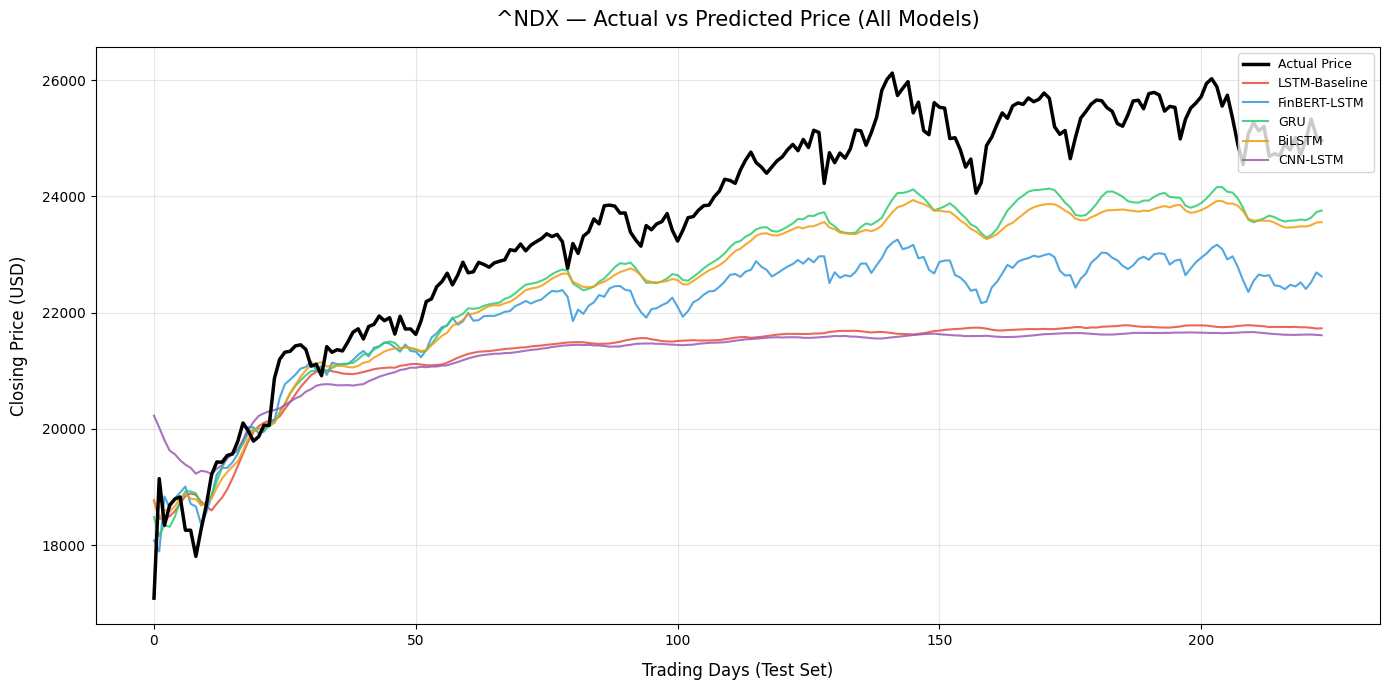

Plot saved for ^NDX


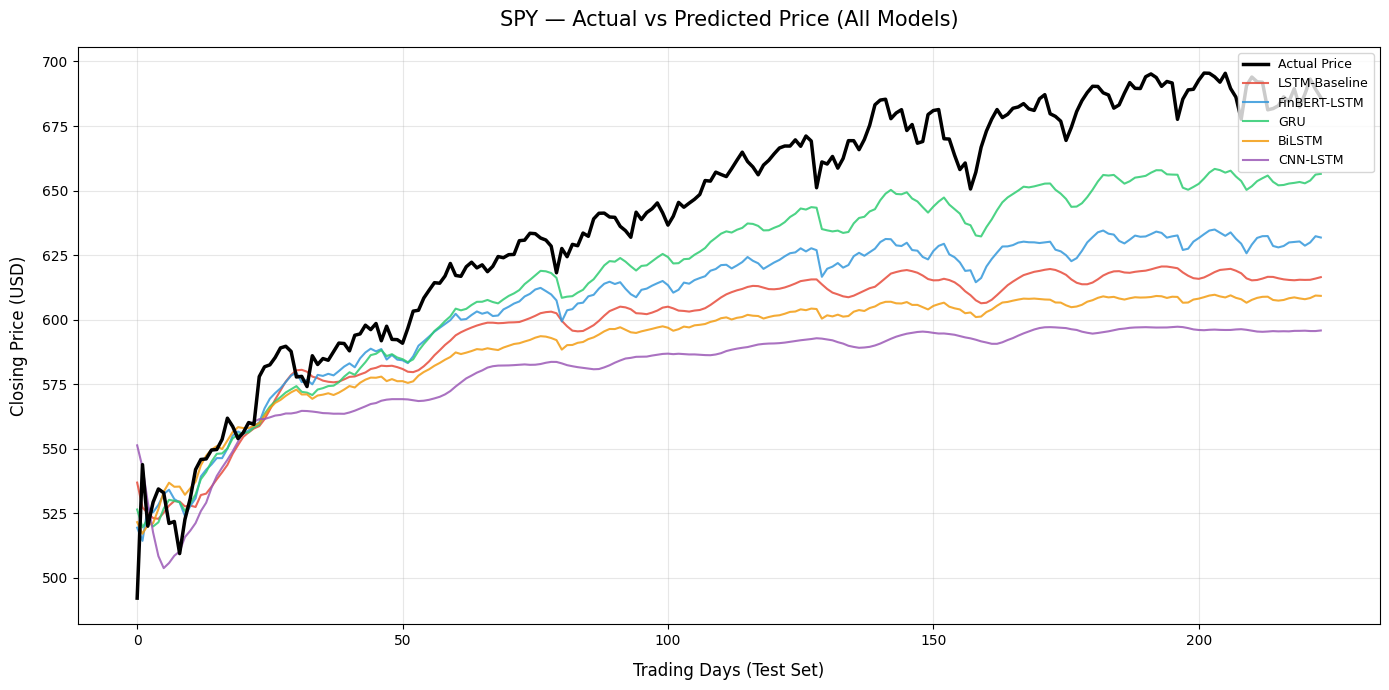

Plot saved for SPY


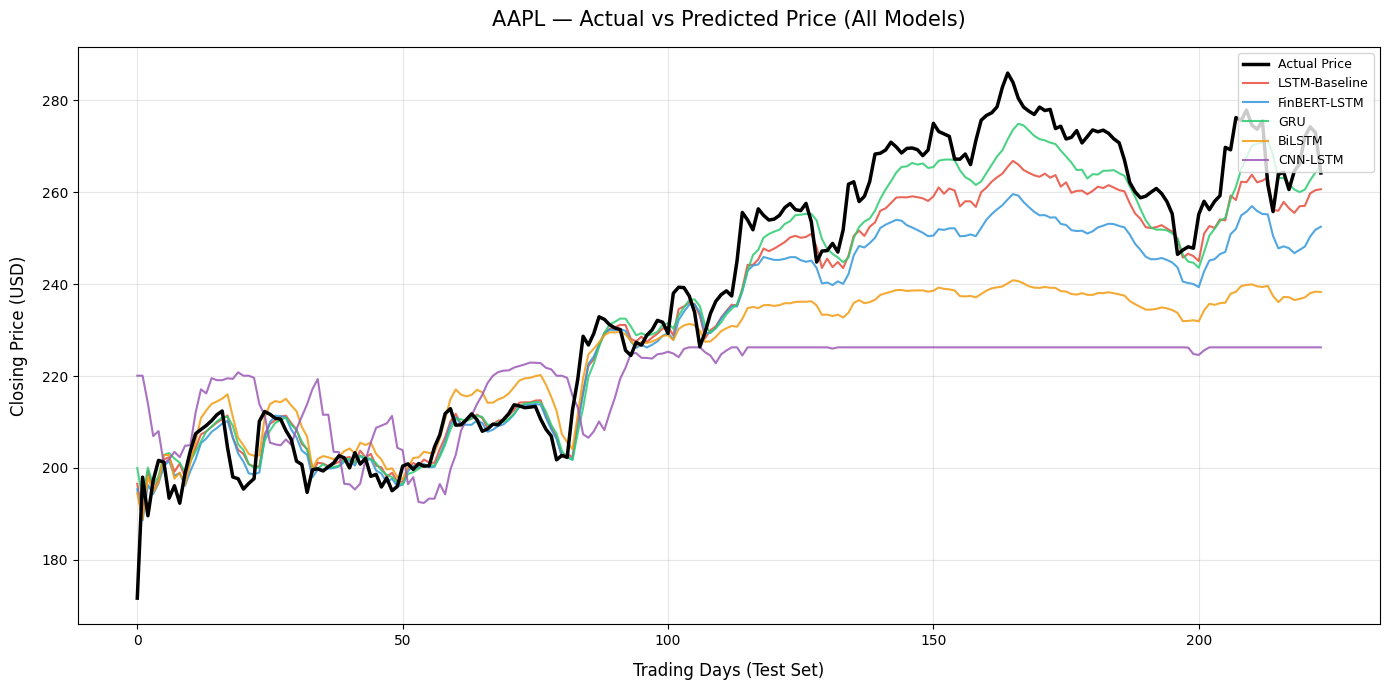

Plot saved for AAPL


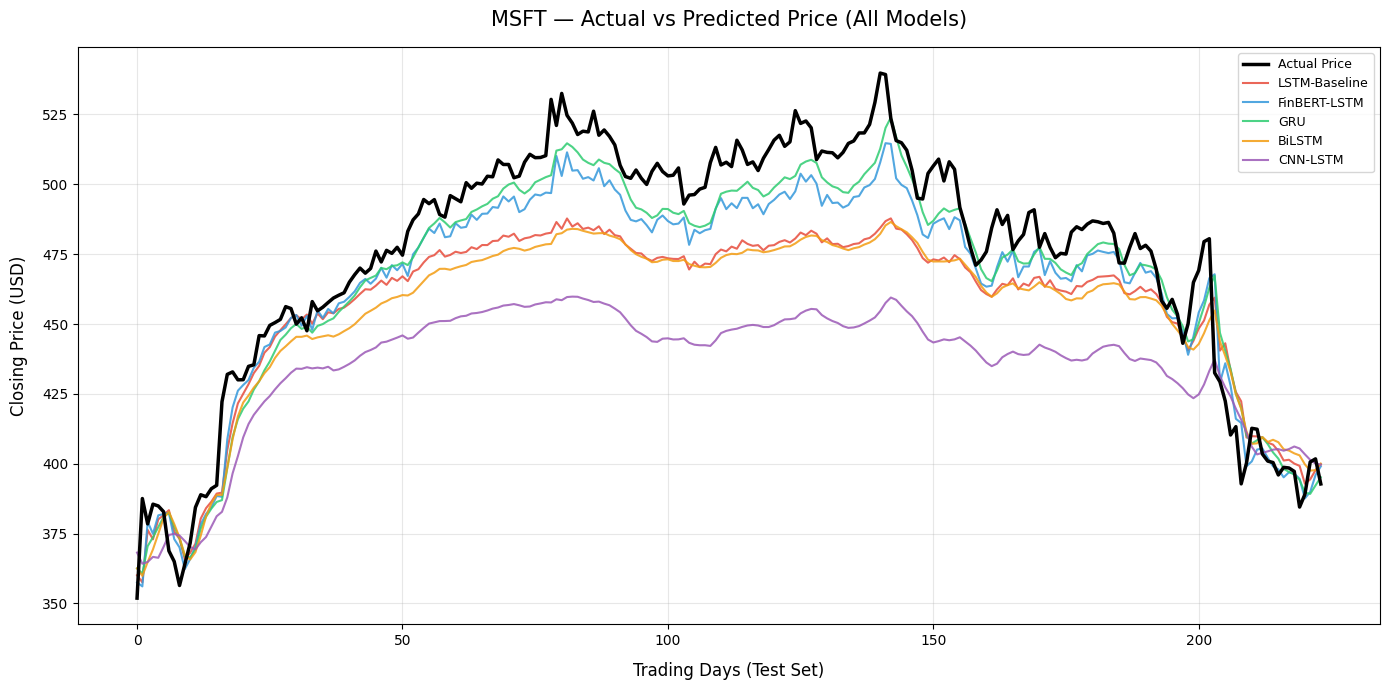

Plot saved for MSFT


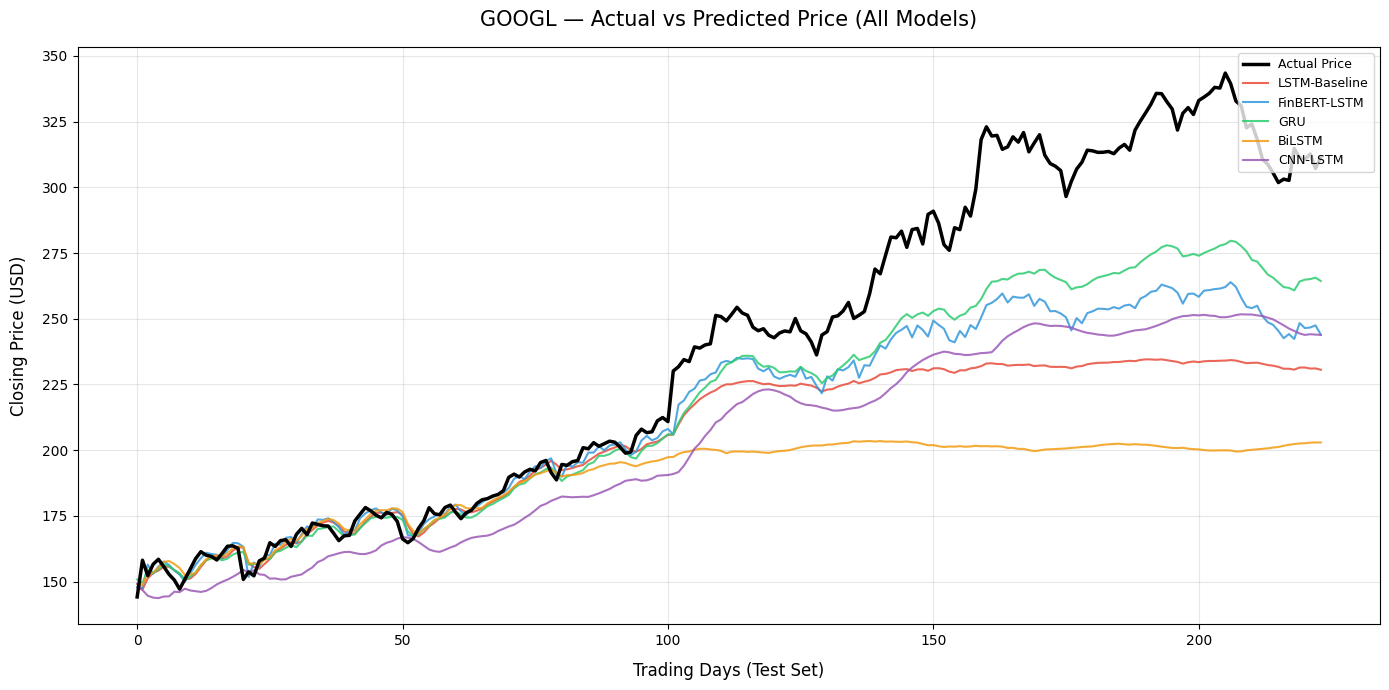

Plot saved for GOOGL


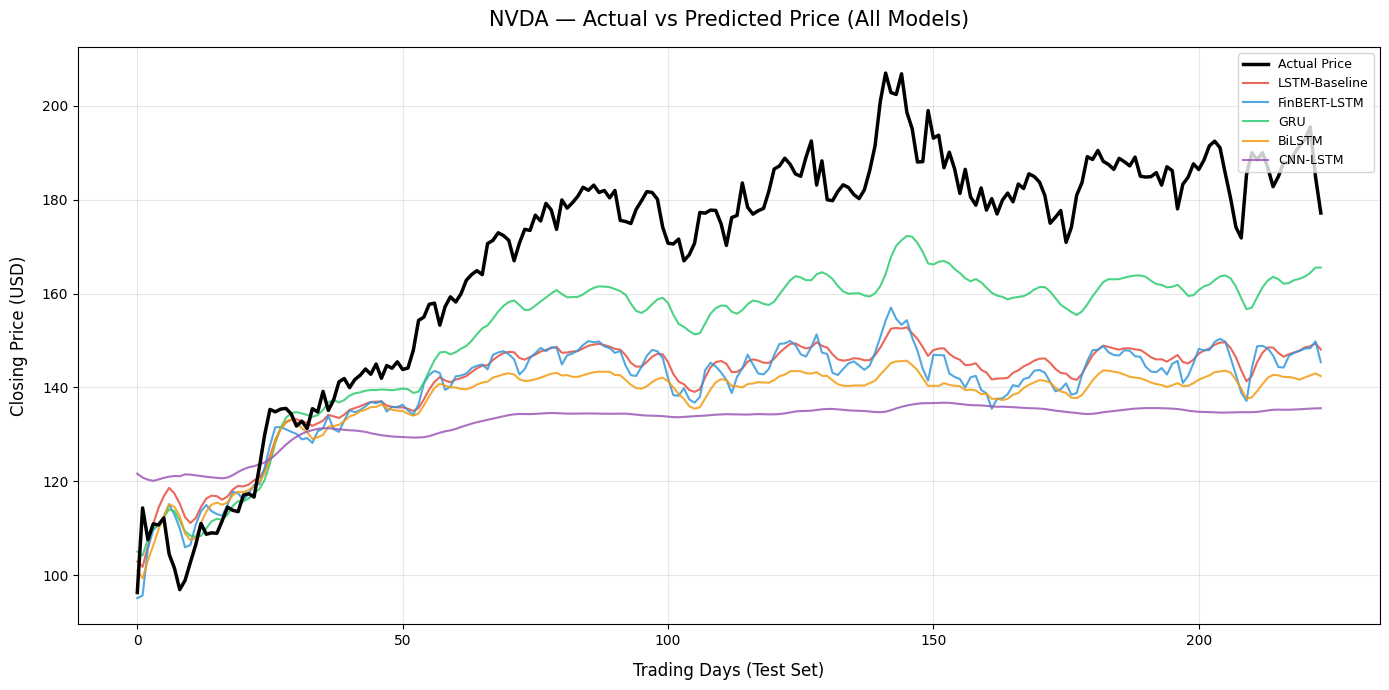

Plot saved for NVDA


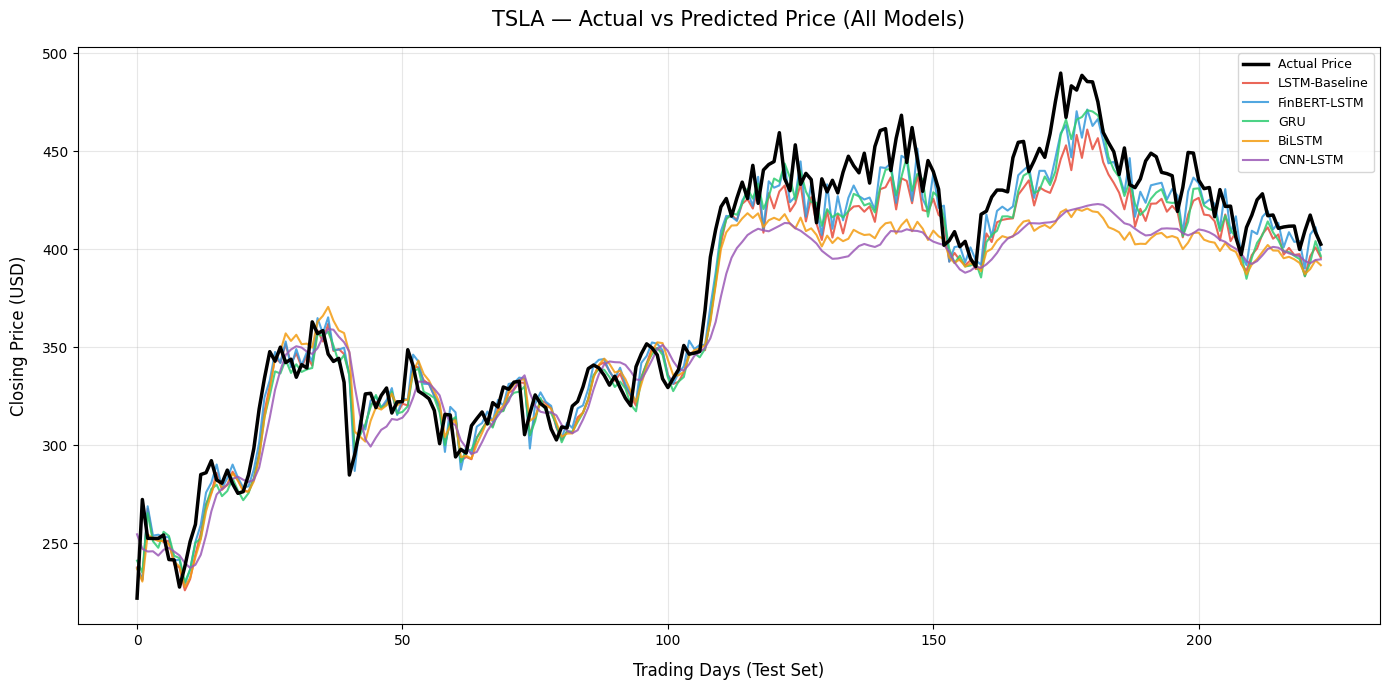

Plot saved for TSLA


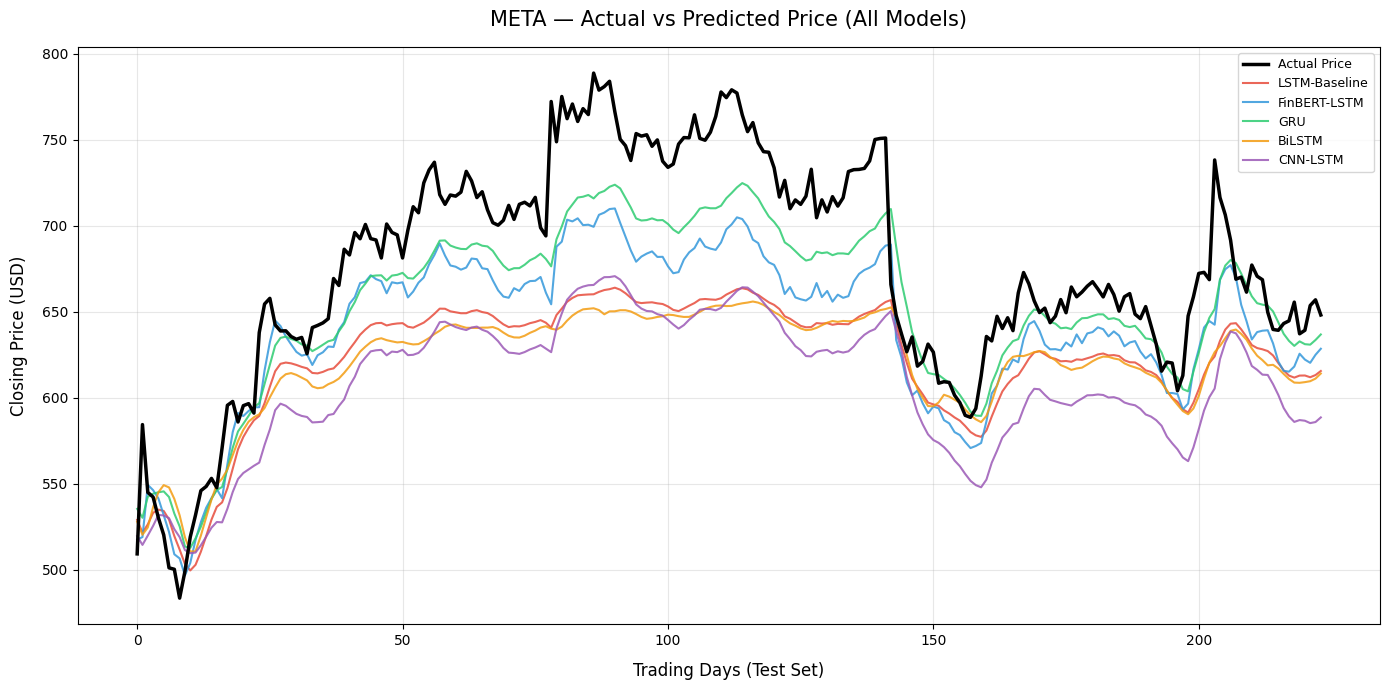

Plot saved for META


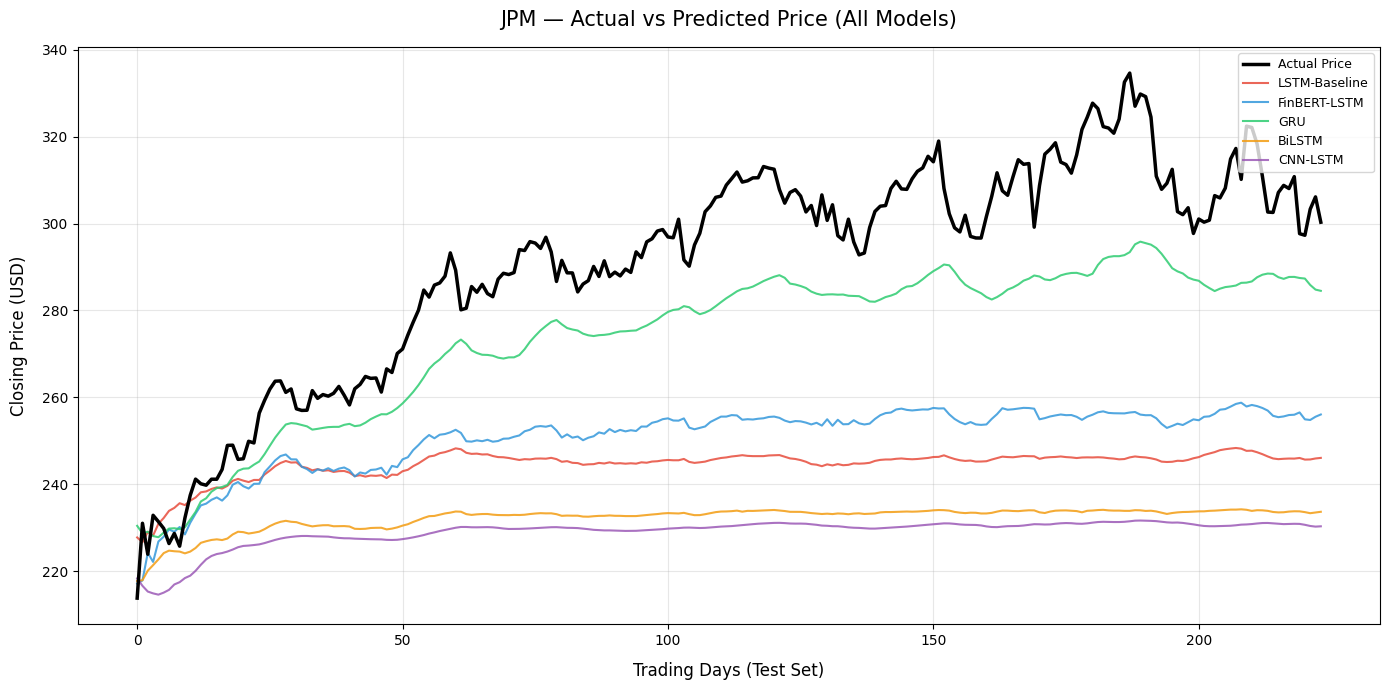

Plot saved for JPM


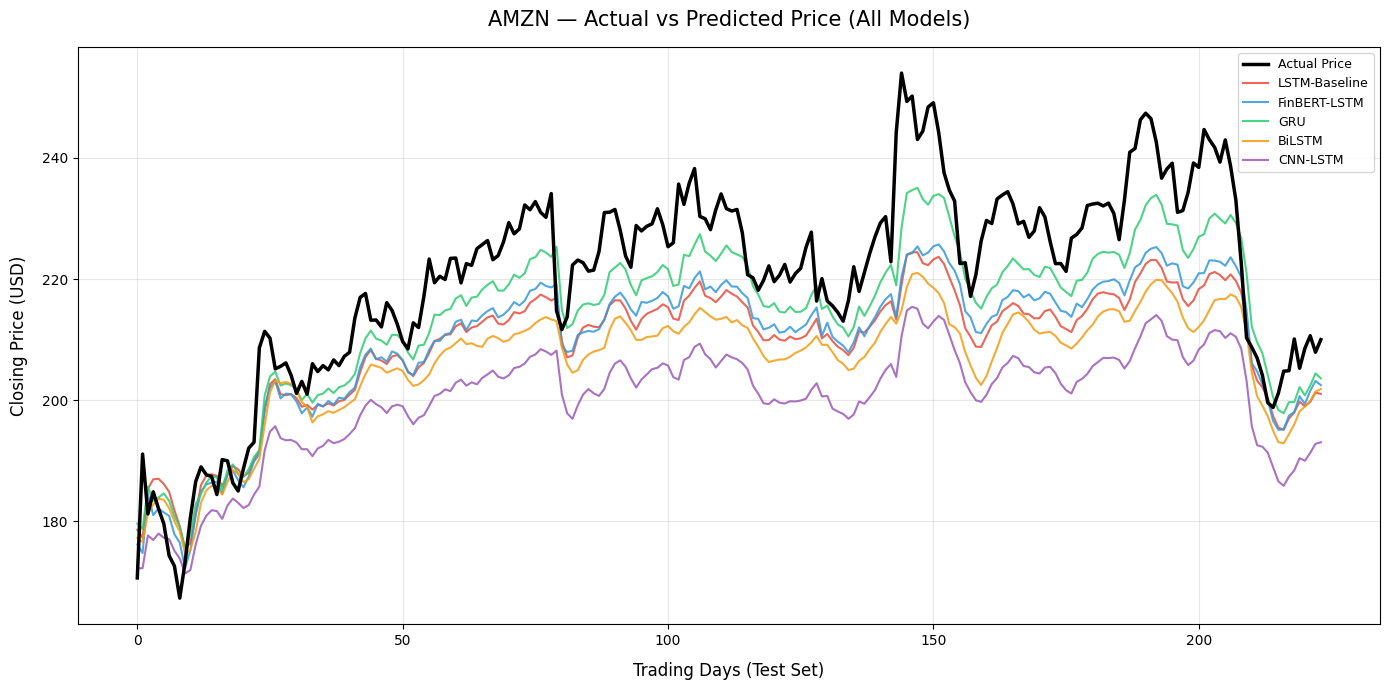

Plot saved for AMZN


In [50]:
for ticker in TICKERS:
    if ticker not in ticker_preds or not ticker_preds[ticker]:
        continue

    ticker_df = features_df[features_df["Ticker"] == ticker].copy().reset_index(drop=True)
    X, y, scaler = build_sequences(ticker_df, SEQUENCE_FEATURES)
    _, _, _, y_te = split_sequences(X, y)
    n_features    = len(SEQUENCE_FEATURES) + 1
    dummy         = np.zeros((len(y_te), n_features))
    dummy[:, -1]  = y_te
    y_true        = scaler.inverse_transform(dummy)[:, -1]

    plt.figure(figsize=(14, 7))
    plt.plot(y_true, linewidth=2.5, color="black", label="Actual Price", zorder=5)

    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
    for idx, (model_name, y_pred) in enumerate(ticker_preds[ticker].items()):
        plt.plot(y_pred, linewidth=1.5, color=colors[idx % len(colors)],
                 label=model_name, alpha=0.85)

    plt.xlabel("Trading Days (Test Set)", fontsize=12, labelpad=10)
    plt.ylabel("Closing Price (USD)", fontsize=12, labelpad=10)
    plt.title(f"{ticker} — Actual vs Predicted Price (All Models)", fontsize=15, pad=15)
    plt.legend(loc="upper right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/{ticker}_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved for {ticker}")

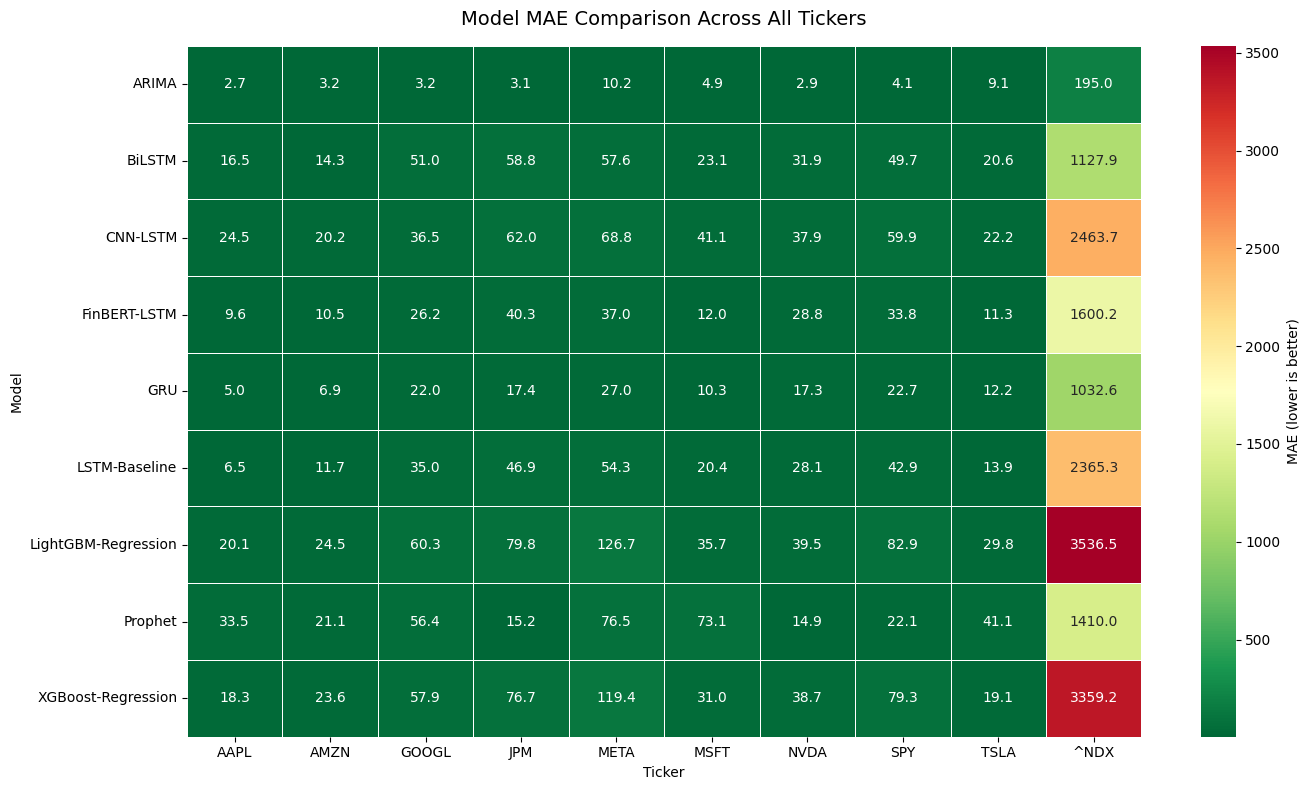

MAE heatmap saved


In [51]:
# Model Comparison Heatmap

if not reg_df.empty:
    pivot = reg_df.pivot_table(values="mae", index="model", columns="ticker", aggfunc="first")
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
        linewidths=0.5, cbar_kws={"label": "MAE (lower is better)"}
    )
    plt.title("Model MAE Comparison Across All Tickers", fontsize=14, pad=15)
    plt.ylabel("Model")
    plt.xlabel("Ticker")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/mae_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("MAE heatmap saved")